In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
#For your own files, it is easier to read them from your own google drive
# this will mount your google drive (after asking permission) with all your directories under the "drive" tab
# to see them, click on the small folder icon in the left margin of the jupyter notebook
# then look under the drive/MyDrive subdirectory
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def get_ds_infos():
    """
    Read the file includes data subject information.

    Data Columns:
    0: code [1-24]
    1: weight [kg]
    2: height [cm]
    3: age [years]
    4: gender [0:Female, 1:Male]

    Returns:
        A pandas DataFrame that contains information about data subjects' attributes
    """

    dss = pd.read_csv("/content/drive/MyDrive/EECS253_Dataset/data_subjects_info.csv")
    print("[INFO] -- Data subjects' information is imported.")

    return dss

def set_data_types(data_types=["userAcceleration"]):
    """
    Select the sensors and the mode to shape the final dataset.

    Args:
        data_types: A list of sensor data type from this list: [attitude, gravity, rotationRate, userAcceleration]

    Returns:
        It returns a list of columns to use for creating time-series from files.
    """
    dt_list = []
    for t in data_types:
        if t != "attitude":
            dt_list.append([t+".x",t+".y",t+".z"])
        else:
            dt_list.append([t+".roll", t+".pitch", t+".yaw"])

    return dt_list

In [4]:
ds_list = get_ds_infos()
ds_list

[INFO] -- Data subjects' information is imported.


,code,weight,height,age,gender
0,1,102,188,46,1
1,2,72,180,28,1
2,3,48,161,28,0
3,4,90,176,31,1
4,5,48,164,23,0
5,6,76,180,28,1
6,7,62,175,30,0
7,8,52,161,24,0
8,9,93,190,32,1
9,10,72,164,31,0


In [5]:
sub_df = pd.DataFrame(ds_list)[["code", "age", "gender", "weight", "height"]]

bins   = [0, 25, 32, 60]
labels = ["youth", "early_adult", "late_adult"]

sub_df["age_group"] = pd.cut(sub_df["age"], bins=bins, labels=labels)

print(sub_df[["code", "age", "age_group", "gender", "weight", "height"]])

# Group by age_group + gender
age_gender_group = sub_df.groupby(["age_group", "gender"])[["weight", "height", "age"]].mean()
print(age_gender_group)


    code  age    age_group  gender  weight  height
0      1   46   late_adult       1     102     188
1      2   28  early_adult       1      72     180
2      3   28  early_adult       0      48     161
3      4   31  early_adult       1      90     176
4      5   23        youth       0      48     164
5      6   28  early_adult       1      76     180
6      7   30  early_adult       0      62     175
7      8   24        youth       0      52     161
8      9   32  early_adult       1      93     190
9     10   31  early_adult       0      72     164
10    11   24        youth       1      70     178
11    12   33   late_adult       1      60     167
12    13   33   late_adult       1      60     178
13    14   35   late_adult       1      70     180
14    15   33   late_adult       1      70     185
15    16   29  early_adult       0      96     172
16    17   26  early_adult       1      76     180
17    18   26  early_adult       0      54     164
18    19   28  early_adult     

/tmp/ipython-input-1969462919.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_group = sub_df.groupby(["age_group", "gender"])[["weight", "height", "age"]].mean()


In [6]:
# group by age_group and gender
groups = sub_df.groupby(["age_group", "gender"])

# age_group: "youth", "early_adult", "late_adult"
# gender: 0 = female, 1 = male

youth_males      = groups.get_group(("youth", 1)).reset_index(drop=True)
youth_females    = groups.get_group(("youth", 0)).reset_index(drop=True)

early_males      = groups.get_group(("early_adult", 1)).reset_index(drop=True)
early_females    = groups.get_group(("early_adult", 0)).reset_index(drop=True)

late_males       = groups.get_group(("late_adult", 1)).reset_index(drop=True)
print(youth_males)
print(youth_females)
print(early_males)
print(early_females)
print(late_males)

   code  age  gender  weight  height age_group
0    11   24       1      70     178     youth
1    20   25       1      88     180     youth
2    21   24       1      52     165     youth
   code  age  gender  weight  height age_group
0     5   23       0      48     164     youth
1     8   24       0      52     161     youth
2    23   25       0      68     170     youth
3    24   18       0      74     173     youth
   code  age  gender  weight  height    age_group
0     2   28       1      72     180  early_adult
1     4   31       1      90     176  early_adult
2     6   28       1      76     180  early_adult
3     9   32       1      93     190  early_adult
4    17   26       1      76     180  early_adult
5    22   31       1     100     186  early_adult
   code  age  gender  weight  height    age_group
0     3   28       0      48     161  early_adult
1     7   30       0      62     175  early_adult
2    10   31       0      72     164  early_adult
3    16   29       0      9

/tmp/ipython-input-3686091453.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = sub_df.groupby(["age_group", "gender"])


In [7]:
youth_df        = sub_df[sub_df["age_group"] == "youth"].reset_index(drop=True)
early_adult_df  = sub_df[sub_df["age_group"] == "early_adult"].reset_index(drop=True)
late_adult_df   = sub_df[sub_df["age_group"] == "late_adult"].reset_index(drop=True)

youth_male_df        = youth_df[youth_df["gender"] == 1].reset_index(drop=True)
youth_female_df      = youth_df[youth_df["gender"] == 0].reset_index(drop=True)

early_adult_male_df  = early_adult_df[early_adult_df["gender"] == 1].reset_index(drop=True)
early_adult_female_df= early_adult_df[early_adult_df["gender"] == 0].reset_index(drop=True)

late_adult_male_df   = late_adult_df[late_adult_df["gender"] == 1].reset_index(drop=True)
late_adult_female_df = late_adult_df[late_adult_df["gender"] == 0].reset_index(drop=True)


In [8]:
print(youth_female_df)

   code  age  gender  weight  height age_group
0     5   23       0      48     164     youth
1     8   24       0      52     161     youth
2    23   25       0      68     170     youth
3    24   18       0      74     173     youth


In [9]:
def creat_time_series(dt_list, act_labels, trial_codes, mode="mag", labeled=True):
    """
    Args:
        dt_list: A list of columns that shows the type of data we want.
        act_labels: list of activites
        trial_codes: list of trials
        mode: It can be "raw" which means you want raw data
        for every dimention of each data type,
        [attitude(roll, pitch, yaw); gravity(x, y, z); rotationRate(x, y, z); userAcceleration(x,y,z)].
        or it can be "mag" which means you only want the magnitude for each data type: (x^2+y^2+z^2)^(1/2)
        labeled: True, if we want a labeld dataset. False, if we only want sensor values.

    Returns:
        It returns a time-series of sensor data.

    """
    num_data_cols = len(dt_list) if mode == "mag" else len(dt_list*3)

    if labeled:
        dataset = np.zeros((0,num_data_cols+7)) # "7" --> [act, code, weight, height, age, gender, trial]
    else:
        dataset = np.zeros((0,num_data_cols))

    ds_list = get_ds_infos()

    print("[INFO] -- Creating Time-Series")
    for sub_id in ds_list["code"]:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act_id]:
                fname = 'A_DeviceMotion_data/'+act+'_'+str(trial)+'/sub_'+str(int(sub_id))+'.csv'
                raw_data = pd.read_csv("/content/drive/MyDrive/EECS253_Dataset/" + fname)
                raw_data = raw_data.drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw_data), num_data_cols))
                for x_id, axes in enumerate(dt_list):
                    if mode == "mag":
                        vals[:,x_id] = (raw_data[axes]**2).sum(axis=1)**0.5
                    else:
                        vals[:,x_id*3:(x_id+1)*3] = raw_data[axes].values
                    vals = vals[:,:num_data_cols]
                if labeled:
                    lbls = np.array([[act_id,
                            sub_id-1,
                            ds_list["weight"][sub_id-1],
                            ds_list["height"][sub_id-1],
                            ds_list["age"][sub_id-1],
                            ds_list["gender"][sub_id-1],
                            trial
                           ]]*len(raw_data))
                    vals = np.concatenate((vals, lbls), axis=1)
                dataset = np.append(dataset,vals, axis=0)
    cols = []
    for axes in dt_list:
        if mode == "raw":
            cols += axes
        else:
            cols += [str(axes[0][:-2])]

    if labeled:
        cols += ["act", "id", "weight", "height", "age", "gender", "trial"]

    dataset = pd.DataFrame(data=dataset, columns=cols)
    return dataset
#________________________________


ACT_LABELS = ["dws","ups", "wlk", "jog", "std", "sit"]
TRIAL_CODES = {
    ACT_LABELS[0]:[1,2,11], ##dws_1,dws_2,dws_11
    ACT_LABELS[1]:[3,4,12], ##ups_3,ups_4,ups_12
    ACT_LABELS[2]:[7,8,15], ##wlk_7,wlk_8,wlk_15
    ACT_LABELS[3]:[9,16], ##jog_9,jog_16
    ACT_LABELS[4]:[6,14], ##std_6,std_14
    ACT_LABELS[5]:[5,13] ##sit_5,sit_13
}

## Here we set parameter to build labeld time-series from dataset of "(A)DeviceMotion_data"
## attitude(roll, pitch, yaw); gravity(x, y, z); rotationRate(x, y, z); userAcceleration(x,y,z)
sdt = ["userAcceleration"]
##sdt = ["attitude", "userAcceleration"]
print("[INFO] -- Selected sensor data types: "+str(sdt))
##act_labels = ACT_LABELS [0:5]
act_labels = ACT_LABELS [0:1] ##dws walk downstairs
print("[INFO] -- Selected activites: "+str(act_labels))
trial_codes = [TRIAL_CODES[act] for act in act_labels]
dt_list = set_data_types(sdt)
dataset = creat_time_series(dt_list, act_labels, trial_codes, mode="raw", labeled=False)
print("[INFO] -- Shape of time-Series dataset:"+str(dataset.shape))
dataset.head()
print(dataset)

[INFO] -- Selected sensor data types: ['userAcceleration']
[INFO] -- Selected activites: ['dws']
[INFO] -- Data subjects' information is imported.
[INFO] -- Creating Time-Series
[INFO] -- Shape of time-Series dataset:(131856, 3)
        userAcceleration.x  userAcceleration.y  userAcceleration.z
0                 0.294894           -0.184493            0.377542
1                 0.219405            0.035846            0.114866
2                 0.010714            0.134701           -0.167808
3                -0.008389            0.136788            0.094958
4                 0.199441            0.353996           -0.044299
...                    ...                 ...                 ...
131851           -0.643846            1.073205           -0.381742
131852           -0.249696            0.752001           -0.485723
131853            0.384208           -0.491243           -0.411753
131854            0.262480           -0.774967           -0.241872
131855            0.175112        

In [10]:
def creat_time_series_for_subject(dt_list, act_labels, trial_codes, ds_dataframe,
                                  subject_id, mode="mag", labeled=False):
    """
    Build time-series for ONE subject (subject_id) across given activities/trials.
    """
    num_data_cols = len(dt_list) if mode == "mag" else len(dt_list) * 3

    if labeled:
        dataset = np.zeros((0, num_data_cols + 7))  # [act, code, weight, height, age, gender, trial]
    else:
        dataset = np.zeros((0, num_data_cols))

    # If you still want ds_list for labels, keep it. Otherwise you can drop it.
    ds_list = ds_dataframe  # or get_ds_infos() if you want all

    print(f"[INFO] -- Creating Time-Series for subject {subject_id}")
    for act_id, act in enumerate(act_labels):
        for trial in trial_codes[act_id]:
            fname = f'A_DeviceMotion_data/{act}_{trial}/sub_{int(subject_id)}.csv'
            raw_data = pd.read_csv("/content/drive/MyDrive/EECS253_Dataset/" + fname)
            raw_data = raw_data.drop(['Unnamed: 0'], axis=1)

            vals = np.zeros((len(raw_data), num_data_cols))

            for x_id, axes in enumerate(dt_list):
                if mode == "mag":
                    vals[:, x_id] = (raw_data[axes]**2).sum(axis=1)**0.5
                else:
                    vals[:, x_id*3:(x_id+1)*3] = raw_data[axes].values
            vals = vals[:, :num_data_cols]

            if labeled:
                # if you really need labels, adjust indexing carefully
                sub_idx = int(subject_id) - 1
                lbls = np.array([[act_id,
                                  subject_id,
                                  ds_list["weight"][sub_idx],
                                  ds_list["height"][sub_idx],
                                  ds_list["age"][sub_idx],
                                  ds_list["gender"][sub_idx],
                                  trial]] * len(raw_data))
                vals = np.concatenate((vals, lbls), axis=1)

            dataset = np.append(dataset, vals, axis=0)

    # Build column names
    cols = []
    for axes in dt_list:
        if mode == "raw":
            cols += axes
        else:
            cols += [str(axes[0][:-2])]

    if labeled:
        cols += ["act", "id", "weight", "height", "age", "gender", "trial"]

    dataset = pd.DataFrame(data=dataset, columns=cols)
    return dataset

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

def build_group_timeseries(group_df, dt_list, act_labels, trial_codes,
                           mode="raw", labeled=False):
    """
    Returns:
        pooled_df: concatenated userAcceleration.x/y/z for all subjects in group
        subj_segments: list of dicts:
            {
              'code': subject_id,
              'start': start_idx_in_pooled,
              'end': end_idx_in_pooled
            }
    """
    pooled_list = []
    subj_segments = []
    cursor = 0

    for _, row in group_df.iterrows():
        sid = int(row["code"])
        ds_sub = creat_time_series_for_subject(
            dt_list,
            act_labels,
            trial_codes,
            group_df,
            subject_id=sid,
            mode=mode,
            labeled=labeled)

        sub_xyz = ds_sub[["userAcceleration.x",
                          "userAcceleration.y",
                          "userAcceleration.z"]].reset_index(drop=True)

        n = len(sub_xyz)
        pooled_list.append(sub_xyz)

        subj_segments.append({
            "code": sid,
            "start": cursor,
            "end": cursor + n
        })
        cursor += n

    pooled_df = pd.concat(pooled_list, axis=0).reset_index(drop=True)
    return pooled_df, subj_segments


In [12]:
# Build pooled training data: youth female
train_df, train_segments = build_group_timeseries(
    youth_female_df,
    dt_list,
    act_labels,
    trial_codes,
    mode="raw",
    labeled=False
)

print("[INFO] Train (youth_female) shape:", train_df.shape)

X_train_all = train_df.values.astype("float32")

# Standardize using *training group* only
mean = X_train_all.mean(axis=0)
std  = X_train_all.std(axis=0) + 1e-8
X_train_norm = (X_train_all - mean) / std

window_size = 64
batch_size  = 32

train_gen = TimeseriesGenerator(
    X_train_norm,
    X_train_norm,
    length=window_size,
    batch_size=batch_size
)

print("[INFO] Number of train sequences:", len(train_gen))


[INFO] -- Creating Time-Series for subject 5
[INFO] -- Creating Time-Series for subject 8
[INFO] -- Creating Time-Series for subject 23
[INFO] -- Creating Time-Series for subject 24
[INFO] Train (youth_female) shape: (20600, 3)
[INFO] Number of train sequences: 642


N−window_size=20600−64=20536

20536 samples÷32 batch size≈642.99

Keras drops the last incomplete batch → 642 batches.

So, each batch has 32 sequences
Total sequences = 642 × 32 = 20544 (close to theoretical 20536)
(minor rounding difference; last few samples are dropped)

We slide a 64-step window over the pooled sequence and train the model to predict the 65th sample. This produces ~20k training examples, which Keras serves in 642 batches of 32 windows each. The network’s output layer has 3 units (x, y, z), and for each batch it outputs a (32, 3) tensor of next-step predictions.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


642/642 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.8138
Epoch 2/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5835
Epoch 3/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5150
Epoch 4/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4876
Epoch 5/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5093
Epoch 6/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4836
Epoch 7/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5139
Epoch 8/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4369
Epoch 9/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4701
Epoch 10/10
642/642 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4696


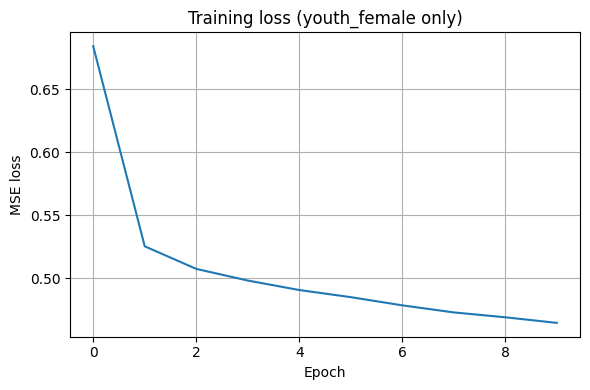

In [13]:
n_features = 3
n_hidden   = 16

model = Sequential()
model.add(SimpleRNN(
    n_hidden,
    activation='tanh',
    input_shape=(window_size, n_features)
))
model.add(Dense(n_features))  # predict next 3D IMU

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(train_gen, epochs=10)

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss (youth_female only)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
def subject_mse_profile(X_sub, model, mean, std, window_size,
                             max_len=None, batch_size=256):
    """
    Compute per-time-step MSE for a single subject's sequence.

    X_sub       : (N, 3) raw IMU for that subject
    max_len     : optionally truncate to this many samples for speed
    Returns:
        mse : np.array of length N - window_size (or truncated)
    """
    if max_len is not None and len(X_sub) > max_len:
        X_sub = X_sub[:max_len]

    Xn = (X_sub - mean) / std
    N  = len(Xn)

    if N <= window_size + 1:
        return np.array([])

    X_in  = []
    y_true = []
    for i in range(N - window_size):
        X_in.append(Xn[i:i+window_size])
        y_true.append(Xn[i+window_size])

    X_in   = np.array(X_in, dtype="float32")
    y_true = np.array(y_true, dtype="float32")

    y_pred = model.predict(X_in, batch_size=batch_size, verbose=0)

    mse = np.mean((y_true - y_pred)**2, axis=1)
    return mse


In [15]:
# Baseline: how well do we predict the *training demographic*?
female_stats = []
MAX_LEN_PER_SUBJECT = None  # or e.g. 5000 for speed

# we still have train_segments and X_train_all for females
for seg in train_segments:
    sid   = seg["code"]
    start = seg["start"]
    end   = seg["end"]

    X_sub = X_train_all[start:end]

    mse = subject_mse_profile(
        X_sub,
        model,
        mean,
        std,
        window_size,
        max_len=MAX_LEN_PER_SUBJECT
    )

    if mse.size == 0:
        continue

    female_stats.append({
        "code": sid,
        "avg_mse": mse.mean(),
        "std_mse": mse.std()
    })

female_df_stats = pd.DataFrame(female_stats)
print("\n[INFO] Youth_female prediction error summary:")
print(female_df_stats)



[INFO] Youth_female prediction error summary:
   code   avg_mse   std_mse
0     5  0.289572  0.723706
1     8  0.356084  0.949043
2    23  0.180818  0.474029
3    24  1.355208  2.766709


In [16]:
early_df = sub_df[sub_df["age_group"] == "early_adult"].reset_index(drop=True)
early_male_df = early_df[early_df["gender"] == 1].reset_index(drop=True)

In [17]:
# Build pooled test data: early adult male
test_df, test_segments = build_group_timeseries(
    early_male_df,
    dt_list,
    act_labels,
    trial_codes,
    mode="raw",
    labeled=False
)

print("[INFO] Test (Early Adult) shape:", test_df.shape)

X_test_all = test_df.values.astype("float32")

male_stats = []

for seg in test_segments:
    sid   = seg["code"]
    start = seg["start"]
    end   = seg["end"]

    X_sub = X_test_all[start:end]

    mse = subject_mse_profile(
        X_sub,
        model,
        mean,
        std,
        window_size,
        max_len=MAX_LEN_PER_SUBJECT
    )

    if mse.size == 0:
        continue

    male_stats.append({
        "code": sid,
        "avg_mse": mse.mean(),
        "std_mse": mse.std()
    })

male_df_stats = pd.DataFrame(male_stats)
print("\n[INFO] Early Adult prediction error summary (using female-trained model):")
print(male_df_stats)


[INFO] -- Creating Time-Series for subject 2
[INFO] -- Creating Time-Series for subject 4
[INFO] -- Creating Time-Series for subject 6
[INFO] -- Creating Time-Series for subject 9
[INFO] -- Creating Time-Series for subject 17
[INFO] -- Creating Time-Series for subject 22
[INFO] Test (Early Adult) shape: (32830, 3)

[INFO] Early Adult prediction error summary (using female-trained model):
   code   avg_mse   std_mse
0     2  0.604849  2.588324
1     4  1.832183  4.558911
2     6  0.592668  1.585986
3     9  0.654713  1.774464
4    17  0.634870  2.004722
5    22  0.886031  1.965556


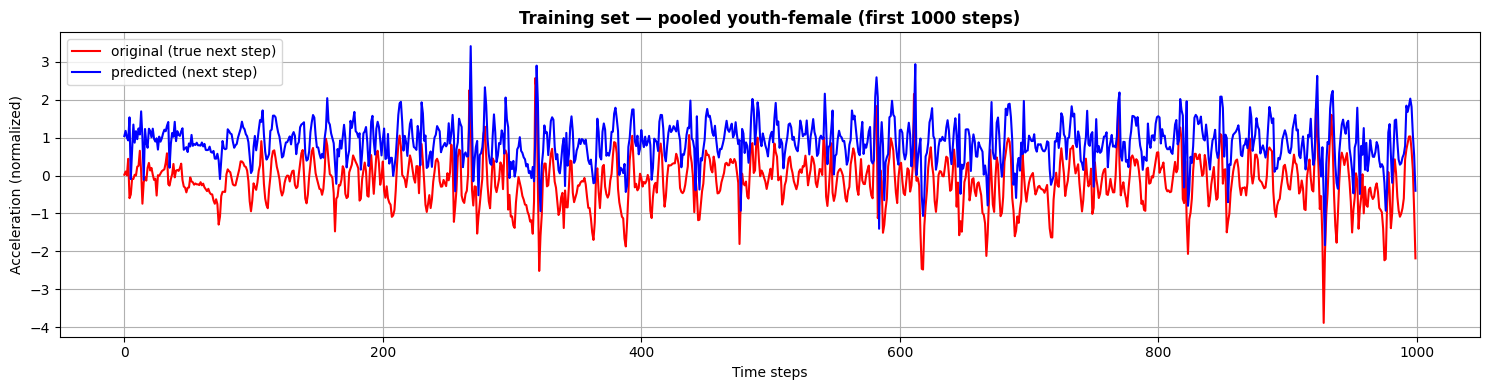

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Plot the Pooled youth-female training results
# -----------------------------------------

T = 1000        # number of timepoints to visualize
L = window_size # history length

# Make sure we don't exceed the signal length
N = len(X_train_norm)
T = min(T, N - L - 1)

segment = X_train_norm[:L + T]        # shape: (L+T, 3)

X_in   = []
y_true = []

for i in range(T):
    X_in.append(segment[i : i + L])   # window [i ... i+L-1]
    y_true.append(segment[i + L])     # next sample at i+L

X_in   = np.array(X_in, dtype="float32")     # (T, L, 3)
y_true = np.array(y_true, dtype="float32")   # (T, 3)

y_pred = model.predict(X_in, batch_size=64, verbose=0)   # (T, 3)

x_input = segment[:T, 0]
x_true  = y_true[:, 0]      # true next-step x
x_pred  = y_pred[:, 0]      # predicted next-step x

plt.figure(figsize=(15,4), linewidth=1)
plt.plot(x_true,  'r', label='original (true next step)')
plt.plot(x_pred + 1,  'b', label='predicted (next step)')

plt.title("Training set — pooled youth-female (first {} steps)".format(T),
          fontweight="bold")
plt.xlabel("Time steps")
plt.ylabel("Acceleration (normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


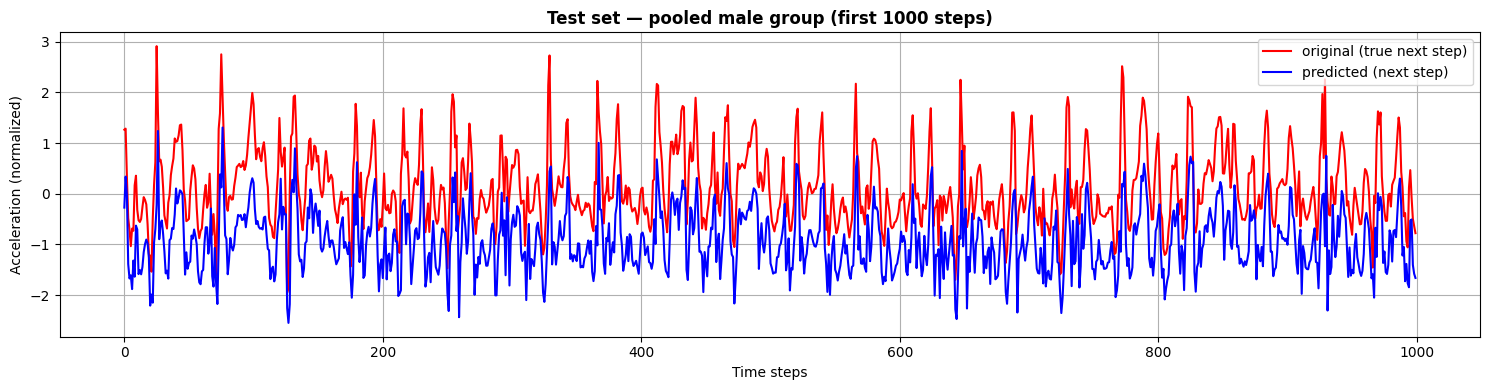

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Plot the Pooled early adult male test results
# -----------------------------------------

T = 1000        # number of timepoints to visualize (adjust if needed)
L = window_size # history length

# Normalize male test data using *training* mean/std
X_test_norm = (X_test_all - mean) / std

N_test = len(X_test_norm)
T = min(T, N_test - L - 1)

segment_test = X_test_norm[:L + T]        # shape: (L+T, 3)

X_in_test   = []
y_true_test = []

for i in range(T):
    X_in_test.append(segment_test[i : i + L])   # window [i ... i+L-1]
    y_true_test.append(segment_test[i + L])     # next sample at i+L

X_in_test   = np.array(X_in_test, dtype="float32")     # (T, L, 3)
y_true_test = np.array(y_true_test, dtype="float32")   # (T, 3)

y_pred_test = model.predict(X_in_test, batch_size=64, verbose=0)   # (T, 3)

x_input_m = segment_test[:T, 0]     # input signal (IMU x)
x_true_m  = y_true_test[:, 0]       # true next-step x
x_pred_m  = y_pred_test[:, 0]       # predicted next-step x

plt.figure(figsize=(15,4), linewidth=1)

offset = 1

plt.plot(x_true_m,          'r', label='original (true next step)')
plt.plot(x_pred_m  - offset,'b', label='predicted (next step)')

plt.title("Test set — pooled male group (first {} steps)".format(T),
          fontweight="bold")
plt.xlabel("Time steps")
plt.ylabel("Acceleration (normalized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


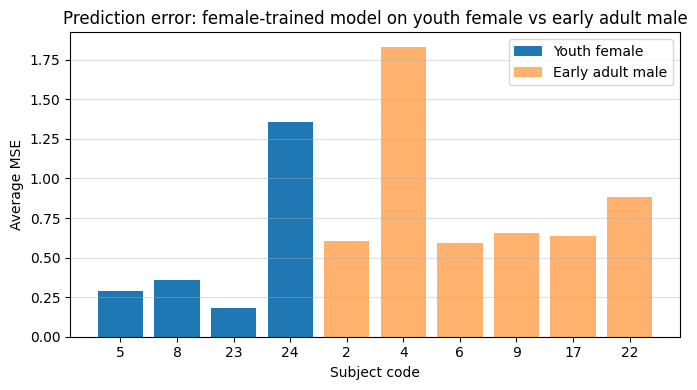

In [20]:
plt.figure(figsize=(7,4))
plt.bar(female_df_stats["code"].astype(str),
        female_df_stats["avg_mse"],
        label="Youth female")
plt.bar(male_df_stats["code"].astype(str),
        male_df_stats["avg_mse"],
        alpha=0.6,
        label="Early adult male")
plt.xlabel("Subject code")
plt.ylabel("Average MSE")
plt.title("Prediction error: female-trained model on youth female vs early adult male")
plt.legend()
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


APPROACH 1 ends here.

PCA beyond this point.

In [21]:
# Map group names to their DataFrames
group_frames = {
    "youth_male":         youth_male_df,
    "youth_female":       youth_female_df,
    "early_adult_male":   early_adult_male_df,
    "early_adult_female": early_adult_female_df,
    "late_adult_male":    late_adult_male_df,
    "late_adult_female":  late_adult_female_df,
}

# Container: for each group, store per-subject datasets + age
group_datasets = {}

for group_name, df_group in group_frames.items():
    print(f"\n[INFO] -- Processing group: {group_name}")
    group_datasets[group_name] = []

    for _, row in df_group.iterrows():
        sid  = int(row["code"])   # subject ID from 1..24
        age  = int(row["age"])

        print(f"  [INFO] -- Loading subject {sid} (age {age})")

        ds_sub = creat_time_series_for_subject(
            dt_list,
            act_labels,
            trial_codes,
            df_group,
            subject_id=sid,
            mode="raw",
            labeled=False
        )

        print(f"    → dataset shape: {ds_sub.shape}")

        group_datasets[group_name].append({
            "code": sid,
            "age": age,
            "dataset": ds_sub
        })


[INFO] -- Processing group: youth_male
  [INFO] -- Loading subject 11 (age 24)
[INFO] -- Creating Time-Series for subject 11
    → dataset shape: (5736, 3)
  [INFO] -- Loading subject 20 (age 25)
[INFO] -- Creating Time-Series for subject 20
    → dataset shape: (5752, 3)
  [INFO] -- Loading subject 21 (age 24)
[INFO] -- Creating Time-Series for subject 21
    → dataset shape: (7509, 3)

[INFO] -- Processing group: youth_female
  [INFO] -- Loading subject 5 (age 23)
[INFO] -- Creating Time-Series for subject 5
    → dataset shape: (5049, 3)
  [INFO] -- Loading subject 8 (age 24)
[INFO] -- Creating Time-Series for subject 8
    → dataset shape: (5784, 3)
  [INFO] -- Loading subject 23 (age 25)
[INFO] -- Creating Time-Series for subject 23
    → dataset shape: (6220, 3)
  [INFO] -- Loading subject 24 (age 18)
[INFO] -- Creating Time-Series for subject 24
    → dataset shape: (3547, 3)

[INFO] -- Processing group: early_adult_male
  [INFO] -- Loading subject 2 (age 28)
[INFO] -- Creating

In [22]:
group_datasets

{'youth_male': [{'code': 11,
   'age': 24,
   'dataset':       userAcceleration.x  userAcceleration.y  userAcceleration.z
   0               0.393342           -0.419683           -0.251210
   1               0.304991           -0.676491           -0.332036
   2              -0.054848           -0.648516           -0.130527
   3              -0.169463           -0.635826           -0.069866
   4              -0.254569           -0.564230           -0.032506
   ...                  ...                 ...                 ...
   5731            0.173149            0.392688            0.126516
   5732           -0.049709            0.551688            0.092937
   5733           -0.121333           -0.110651           -0.205238
   5734            0.009335           -0.378401           -0.241676
   5735            0.159747           -0.472585           -0.350150
   
   [5736 rows x 3 columns]},
  {'code': 20,
   'age': 25,
   'dataset':       userAcceleration.x  userAcceleration.y  userAcce

In [23]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

def run_pca(group_name, group_data, plot_len=500):
    """
    group_name : 'youth_male', 'early_adult_female', etc.
    group_data : list of dicts { 'code': id, 'age': age, 'dataset': df }

    Returns:
        pca : fitted PCA object (with 1 component)
        pc1 : 1D numpy array, the first principal component over time
    """
    if not group_data:
        print(f"\n[INFO] Skipping PCA for {group_name} (no subjects).")
        return None, None

    print(f"\n[INFO] Running 1D PCA for group: {group_name}")

    pooled = []

    for entry in group_data:
        df = entry["dataset"]

        imu = df[["userAcceleration.x",
                  "userAcceleration.y",
                  "userAcceleration.z"]].values

        pooled.append(imu)

    if len(pooled) == 0:
        print(f"[INFO]   No IMU data for {group_name}, skipping.")
        return None, None

    pooled = np.concatenate(pooled, axis=0)
    print(f"[INFO]   Pooled shape for {group_name}: {pooled.shape}")

    X = pooled.astype(float)
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(X).reshape(-1)   # shape: (T,)

    L = min(plot_len, len(pc1))

    plt.figure(figsize=(12, 6))

    # Original 3 axes (first L samples)
    plt.subplot(2, 1, 1)
    plt.title(f"{group_name} — Original IMU axes (first {L} samples)")
    for i, label in enumerate(["x", "y", "z"]):
        plt.plot(X[:L, i], label=f"acc_{label}")
    plt.grid(True)
    plt.legend()

    # 1D PCA signal
    plt.subplot(2, 1, 2)
    plt.title(f"{group_name} — 1D PCA projection (PC)")
    plt.plot(pc1[:L], label="PC", color="black")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return pca, pc1


[INFO] Running 1D PCA for group: youth_male
[INFO]   Pooled shape for youth_male: (18997, 3)


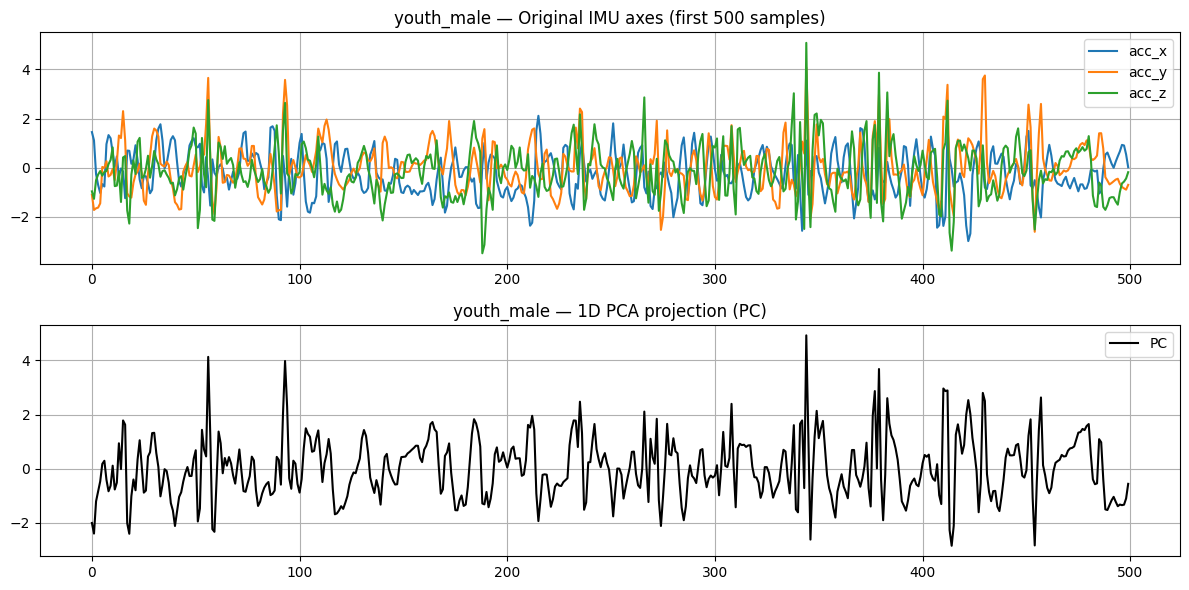


[INFO] Running 1D PCA for group: youth_female
[INFO]   Pooled shape for youth_female: (20600, 3)


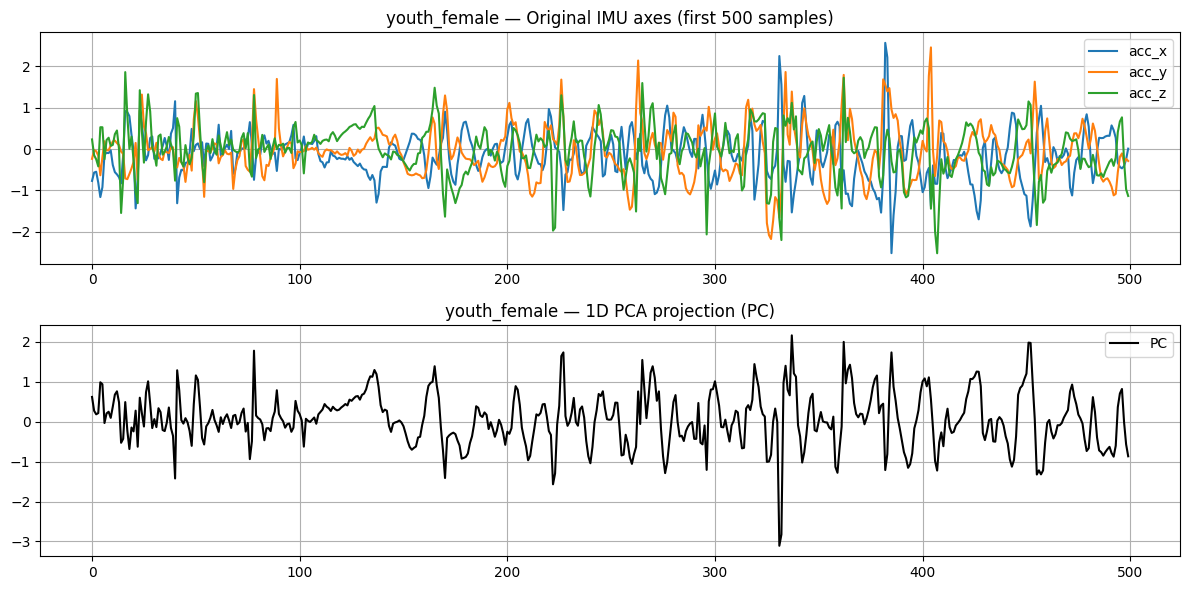


[INFO] Running 1D PCA for group: early_adult_male
[INFO]   Pooled shape for early_adult_male: (32830, 3)


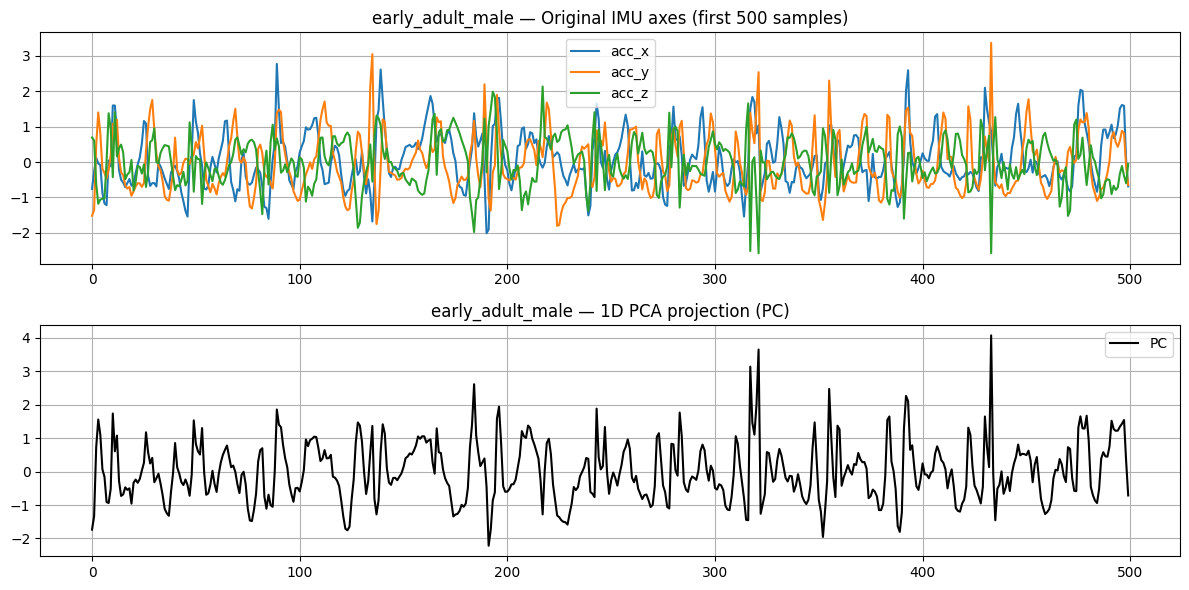


[INFO] Running 1D PCA for group: early_adult_female
[INFO]   Pooled shape for early_adult_female: (37213, 3)


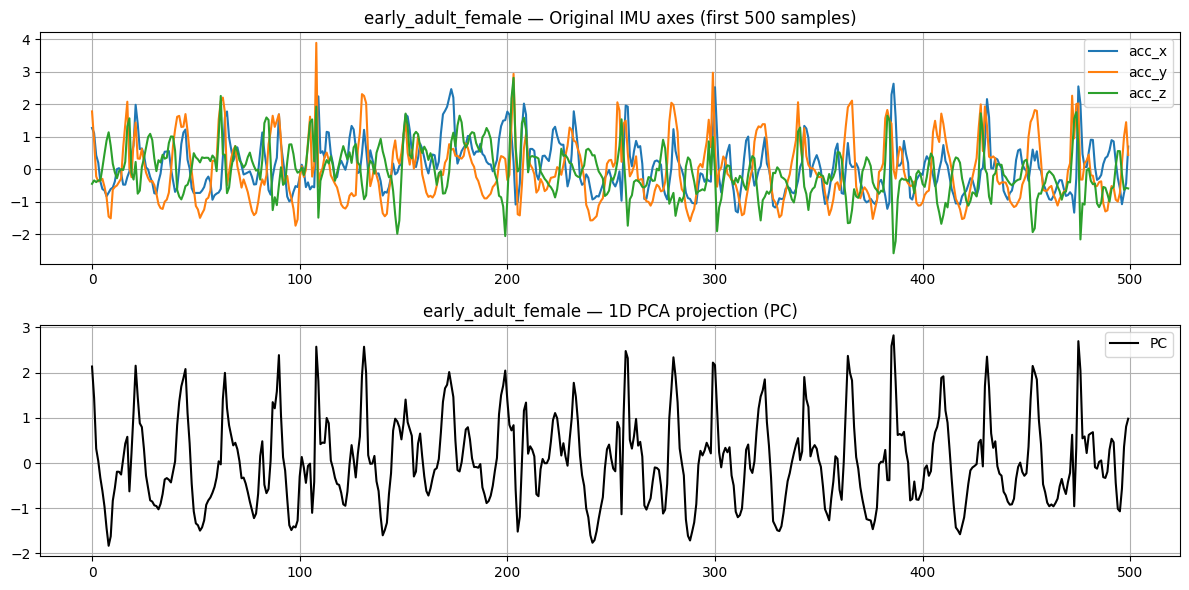


[INFO] Running 1D PCA for group: late_adult_male
[INFO]   Pooled shape for late_adult_male: (22216, 3)


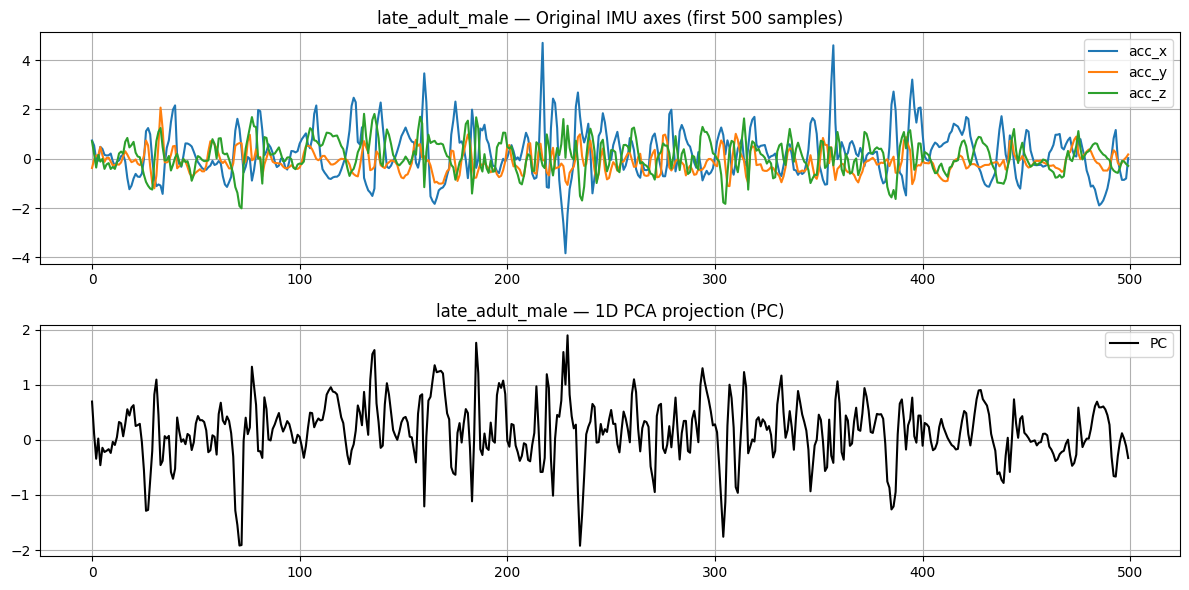


[INFO] Skipping PCA for late_adult_female (no subjects).


In [24]:
group_pc1 = {}  # store the 1D PCA signal per group

for group_name, group_data in group_datasets.items():
    pca, pc1 = run_pca(group_name, group_data)
    group_pc1[group_name] = {
        "pca": pca,
        "pc1": pc1
    }

In [25]:
import pandas as pd

pca_loadings = []

for group_name, info in group_pc1.items():
    pca = info["pca"]

    # Some groups may be empty
    if pca is None:
        continue

    # Extract 3 loadings for PC1
    w_x, w_y, w_z = pca.components_[0]

    pca_loadings.append({
        "group": group_name,
        "PC1_x": w_x,
        "PC1_y": w_y,
        "PC1_z": w_z
    })

pca_loadings_df = pd.DataFrame(pca_loadings)
print(pca_loadings_df)


                group     PC1_x     PC1_y     PC1_z
0          youth_male -0.518313  0.636103  0.571599
1        youth_female -0.673385  0.255567  0.693714
2    early_adult_male  0.505714  0.616619 -0.603353
3  early_adult_female  0.689580  0.608007 -0.393455
4     late_adult_male -0.090571 -0.696003  0.712304


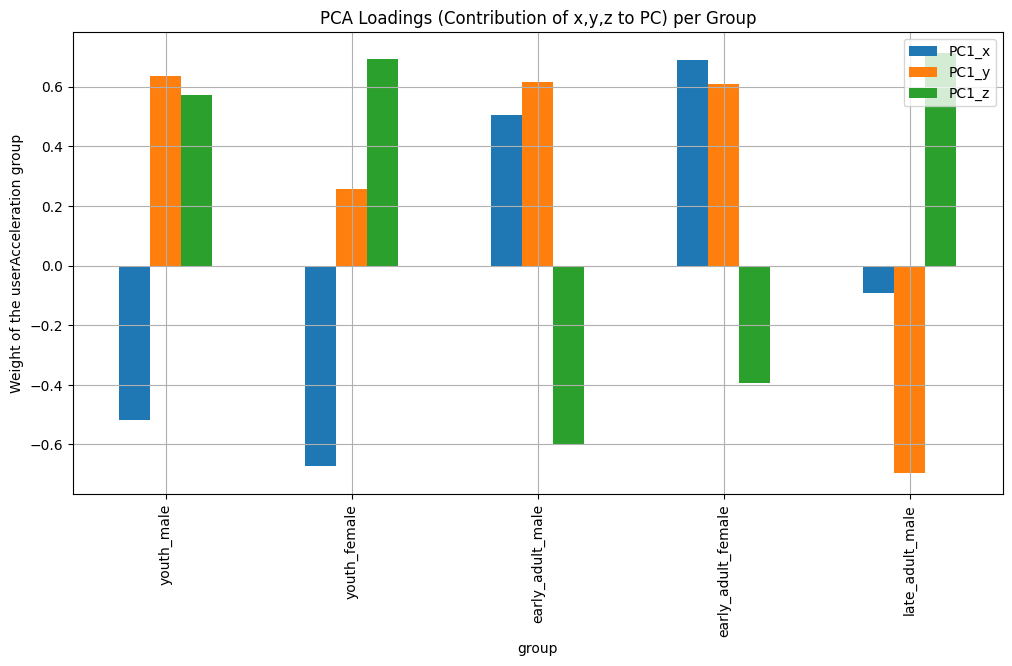

In [26]:
pca_loadings_df.set_index("group").plot(kind="bar", figsize=(12,6))
plt.title("PCA Loadings (Contribution of x,y,z to PC) per Group")
plt.ylabel("Weight of the userAcceleration group")
plt.grid(True)
plt.show()


Since the axes/weights of each userAcceleration axis contributes to the same cause with different signs. We can use the absolute value rather than treating it as positive or negative impact on the PCA.

In [27]:
pca_loadings_abs = pca_loadings_df.copy()
pca_loadings_abs["PC1_x"] = pca_loadings_abs["PC1_x"].abs()
pca_loadings_abs["PC1_y"] = pca_loadings_abs["PC1_y"].abs()
pca_loadings_abs["PC1_z"] = pca_loadings_abs["PC1_z"].abs()

In [28]:
pca_loadings_abs

,group,PC1_x,PC1_y,PC1_z
0,youth_male,0.518313,0.636103,0.571599
1,youth_female,0.673385,0.255567,0.693714
2,early_adult_male,0.505714,0.616619,0.603353
3,early_adult_female,0.689580,0.608007,0.393455
4,late_adult_male,0.090571,0.696003,0.712304


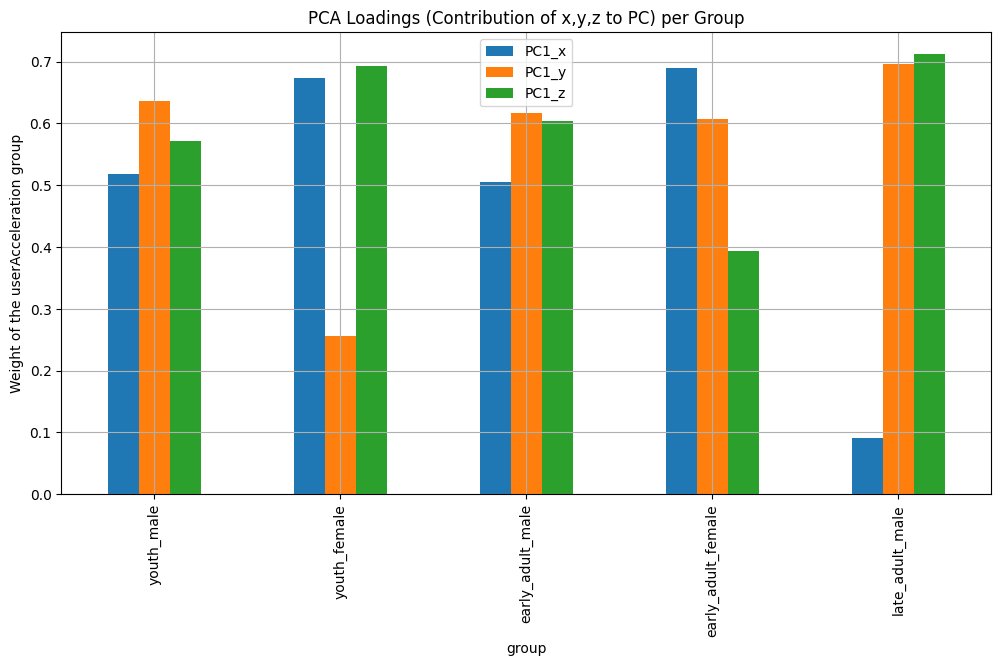

In [29]:
pca_loadings_abs.set_index("group").plot(kind="bar", figsize=(12,6))
plt.title("PCA Loadings (Contribution of x,y,z to PC) per Group")
plt.ylabel("Weight of the userAcceleration group")
plt.grid(True)
plt.show()


USER ACCELERATION X/Y/Z Classification Problem treatment below.

In [30]:
ACT_LABELS = ["dws","ups", "wlk", "jog", "std", "sit"]
TRIAL_CODES = {
    ACT_LABELS[0]:[1,2,11],
    ACT_LABELS[1]:[3,4,12],
    ACT_LABELS[2]:[7,8,15],
    ACT_LABELS[3]:[9,16],
    ACT_LABELS[4]:[6,14],
    ACT_LABELS[5]:[5,13]
}

sdt = ["userAcceleration"]
print("[INFO] -- Selected sensor data types:", sdt)

# only downstairs (dws)
act_labels = ACT_LABELS[0:1]
print("[INFO] -- Selected activities:", act_labels)

trial_codes = [TRIAL_CODES[act] for act in act_labels]
dt_list = set_data_types(sdt)

# Subject 5
dataset_5 = creat_time_series_for_subject(dt_list, act_labels, trial_codes,
                                          subject_id=5, mode="raw", labeled=False)
print("[INFO] -- Subject 5 shape:", dataset_5.shape)

# Subject 8
dataset_8 = creat_time_series_for_subject(dt_list, act_labels, trial_codes,
                                          subject_id=8, mode="raw", labeled=False)
print("[INFO] -- Subject 8 shape:", dataset_8.shape)

# Subject 24
dataset_24 = creat_time_series_for_subject(dt_list, act_labels, trial_codes,
                                          subject_id=24, mode="raw", labeled=False)
print("[INFO] -- Subject 24 shape:", dataset_24.shape)

[INFO] -- Selected sensor data types: ['userAcceleration']
[INFO] -- Selected activities: ['dws']


TypeError: creat_time_series_for_subject() missing 1 required positional argument: 'ds_dataframe'

In [ ]:
dataset_5

In [ ]:
dataset_8

In [ ]:
dataset_24

In [ ]:
# df_8: T8 × 3 DataFrame with columns ["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]
df_8 = dataset_8[["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]].copy()

In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
## Lecture 5
predict_length = 16          # past 16 timesteps
n_features = 3               # x, y, z

gen_imu = TimeseriesGenerator(
    df_8.values,      # input series
    df_8.values,      # target series
    length=predict_length,
    batch_size=32            # can be >1 here
)

print("One sample shape:", gen_imu[0][0].shape, "->", gen_imu[0][1].shape)
# should be: (batch_size, 16, 3) -> (batch_size, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

n_hidden = 8

model = Sequential()
model.add(SimpleRNN(n_hidden, activation='tanh',
                    input_shape=(predict_length, n_features)))
model.add(Dense(n_features))      # predict next 3-dim IMU sample
model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(gen_imu, epochs=10)


In [ ]:
df_5 = dataset_5[["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]]
df_8 = dataset_8[["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]]
df_24 = dataset_24[["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]]
mixed_df = pd.concat([df_5, df_8, df_24], axis=0).reset_index(drop=True)

gen_mixed = TimeseriesGenerator(
    mixed_df.values,
    mixed_df.values,
    length=predict_length,
    batch_size=1
)

# 1. Predict on entire mixed series
pred_mixed = model.predict(gen_mixed)

# 2. True targets from the mixed signal
orig_mixed = mixed_df.values[predict_length:]
orig_mixed = orig_mixed[:len(pred_mixed)]   # align lengths

# 3. Compute error
err = np.mean((orig_mixed - pred_mixed)**2, axis=1)



In [ ]:
n5  = len(df_5)
n8  = len(df_8)
n24 = len(df_24)

print(n5, n8, n24)


In [ ]:
import numpy as np

idx5_start  = 0
idx5_end    = n5 - predict_length

idx8_start  = idx5_end
idx8_end    = idx5_end + n8

idx24_start = idx8_end
idx24_end   = idx8_end + n24

err_5   = err[idx5_start:idx5_end]
err_8   = err[idx8_start:idx8_end]
err_24  = err[idx24_start:idx24_end]

print("Mean error in subj 5 segment :", np.mean(err_5))
print("Mean error in subj 8 segment :", np.mean(err_8))
print("Mean error in subj 24 segment:", np.mean(err_24))


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(err, label="prediction error")

plt.axvline(idx5_end,  color="red", linestyle="--", label="5→8 boundary")
plt.axvline(idx8_end,  color="green", linestyle="--", label="8→24 boundary")

plt.xlabel("time index (t - predict_length)")
plt.ylabel("MSE error")
plt.title("LSTM prediction error over mixed signal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
window_len = 200

# Slice out error segments
err_5   = err[idx5_start  : idx5_end]
err_8   = err[idx8_start  : idx8_end]
err_24  = err[idx24_start : idx24_end]

import numpy as np

def worst_segment(err_region, window_len=200):
    if len(err_region) <= window_len:
        # if region is too short, just take whole thing
        return 0, len(err_region)
    window_sums = np.array([
        err_region[i:i+window_len].sum()
        for i in range(len(err_region) - window_len)
    ])
    worst_start = int(np.argmax(window_sums))
    worst_end   = worst_start + window_len
    return worst_start, worst_end
window_len = 200  # or whatever you want

w5_s_local,  w5_e_local  = worst_segment(err_5,  window_len)
w8_s_local,  w8_e_local  = worst_segment(err_8,  window_len)
w24_s_local, w24_e_local = worst_segment(err_24, window_len)

print("Subject 5 worst local:",  w5_s_local,  w5_e_local)
print("Subject 8 worst local:",  w8_s_local,  w8_e_local)
print("Subject 24 worst local:", w24_s_local, w24_e_local)



In [ ]:
g5_s  = idx5_start  + w5_s_local
g5_e  = idx5_start  + w5_e_local

g8_s  = idx8_start  + w8_s_local
g8_e  = idx8_start  + w8_e_local

g24_s = idx24_start + w24_s_local
g24_e = idx24_start + w24_e_local

print("Subject 5 worst global:",  g5_s,  g5_e)
print("Subject 8 worst global:",  g8_s,  g8_e)
print("Subject 24 worst global:", g24_s, g24_e)


In [ ]:
orig_5_worst = orig_mixed[g5_s:g5_e, 0]   # channel 0 = userAcceleration.x
pred_5_worst = pred_mixed[g5_s:g5_e, 0]

plt.figure(figsize=(12,4))
plt.plot(orig_5_worst, 'r', label="Original (Subj 5, worst window)")
plt.plot(pred_5_worst, 'b', label="Predicted by Subj-8 model")
plt.xlabel("Samples in worst window")
plt.ylabel("userAcceleration.x")
plt.title("Subject 5 — Worst-Error Window (Model trained on Subject 8)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


In [ ]:
# --- SUBJECT 8 WORST WINDOW ---
orig_8_worst = orig_mixed[g8_s:g8_e, 0]   # channel 0 = userAcceleration.x
pred_8_worst = pred_mixed[g8_s:g8_e, 0]

plt.figure(figsize=(12,4))
plt.plot(orig_8_worst, 'r', label="Original (Subject 8 worst window)")
plt.plot(pred_8_worst, 'b', label="Predicted by Subject-8 model")
plt.xlabel("Samples in worst window")
plt.ylabel("userAcceleration.x")
plt.title("Subject 8 — Worst-Error Window (Model trained on Subject 8)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- SUBJECT 24 WORST WINDOW ---
orig_24_worst = orig_mixed[g24_s:g24_e, 0]   # channel 0 = userAcceleration.x
pred_24_worst = pred_mixed[g24_s:g24_e, 0]

plt.figure(figsize=(12,4))
plt.plot(orig_24_worst, 'r', label="Original (Subject 24 worst window)")
plt.plot(pred_24_worst, 'b', label="Predicted by Subject-8 model")
plt.xlabel("Samples in worst window")
plt.ylabel("userAcceleration.x")
plt.title("Subject 24 — Worst-Error Window (Model trained on Subject 8)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
